<a href="https://colab.research.google.com/github/Eddythemachine/intro_to_cnn/blob/main/intro_to_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Get Data

In [ ]:
import zipfile

# Get File
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-03-13 04:03:10--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.202.207, 173.194.203.207, 74.125.199.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.202.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  85.3MB/s    in 1.2s    

2026-03-13 04:03:12 (85.3 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [ ]:
!ls pizza_steak

test  train


In [ ]:
!ls pizza_steak/train

pizza  steak


In [ ]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [ ]:
import os

# Wallkthrough pizza_steak directory and list number of files
for dirpath, dirnames, filenames, in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} in {dirpath}")

There are 2 in pizza_steak
There are 2 in pizza_steak/test
There are 0 in pizza_steak/test/steak
There are 0 in pizza_steak/test/pizza
There are 2 in pizza_steak/train
There are 0 in pizza_steak/train/steak
There are 0 in pizza_steak/train/pizza


In [ ]:
# The extra file in our pizza_steak dir is ".Ds_Store"
!ls -la pizza_steak

total 16
drwxr-xr-x 4 root root 4096 Mar 13 04:03 .
drwxr-xr-x 1 root root 4096 Mar 13 04:03 ..
drwxr-xr-x 4 root root 4096 Mar 13 04:03 test
drwxr-xr-x 4 root root 4096 Mar 13 04:03 train


In [ ]:
# Import matplotli
import matplotlib.pyplot as plt

num_steak_iamges_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_iamges_train

750

In [ ]:
# Get Class Names
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted((item.name for item in data_dir.glob("*"))))
print(class_names)

['pizza' 'steak']


In [ ]:
# Visualise
import matplotlib.image as mpimg
import random
import os

def view_random_image(target_dir, target_class):
    # Set up target directory - ensure there is a slash between dir and class
    target_folder = os.path.join(target_dir, target_class)

    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)[0]
    img_path = os.path.join(target_folder, random_image)
    print(f"Reading image: {random_image}")

    # Read the image and plot using matplotlib
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")

    print(f"Image shape: {img.shape}")

    return img

Reading image: 2966859.jpg
Image shape: (512, 512, 3)


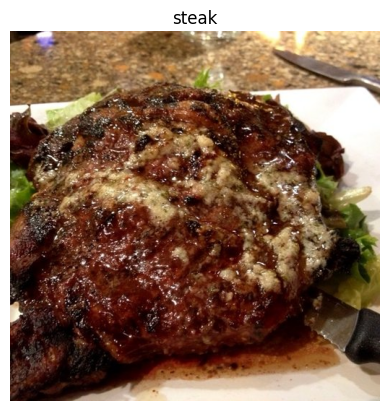

In [ ]:
img = view_random_image(target_dir="pizza_steak/train",
                        target_class="steak")

In [ ]:
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 58,  35,  21],
        [ 59,  36,  22],
        [ 52,  30,  17],
        ...,
        [247, 210, 155],
        [251, 212, 157],
        [255, 216, 161]],

       [[ 56,  33,  19],
        [ 58,  35,  21],
        [ 52,  30,  16],
        ...,
        [242, 205, 150],
        [241, 202, 147],
        [240, 201, 146]],

       [[ 56,  33,  17],
        [ 59,  36,  20],
        [ 54,  33,  16],
        ...,
        [242, 207, 153],
        [239, 202, 147],
        [238, 201, 146]],

       ...,

       [[ 42,  25,  18],
        [ 40,  23,  16],
        [ 37,  18,  11],
        ...,
        [203, 195, 176],
        [203, 192, 174],
        [202, 194, 175]],

       [[ 34,  15,   9],
        [ 30,  11,   5],
        [ 28,   8,   1],
        ...,
        [203, 196, 178],
        [203, 194, 177],
        [200, 193, 175]],

       [[ 26,   7,   1],
        [ 21,   2,   0],
        [ 23,   3,   0],
        ...,
        [201, 194, 17

In [ ]:
# View image shape
img.shape

(512, 512, 3)

# An end to end example

In [ ]:
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

print(f"Training directory: {train_dir}")
print(f"Testing directory: {test_dir}")

Training directory: pizza_steak/train
Testing directory: pizza_steak/test


In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# --- TRAINING DATA ---
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',    # Grabs the 80%
    seed=42
)

# --- VALIDATION DATA (from the train directory) ---
val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',  # Grabs the 20%
    seed=42
)

# --- TEST DATA (from the test directory) ---
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,        # Usually False for testing to keep predictions organized
    seed=42
)

Found 1200 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:

# Build an optimized CNN model (Tiny VGG style but more efficient)
model_1 = tf.keras.models.Sequential([

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 26,999,457 (102.99 MB)

 Trainable params: 26,996,961 (102.99 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [ ]:
# Compile Model with Adam optimizer (often better than SGD)
model_1.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [ ]:
# Callbacks for better training
callbacks = [
    # Reduce learning rate when plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Model checkpoint to save best model
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


In [ ]:
# Fit the model
history_1 = model_1.fit(
    train_data,
    epochs=10,  # Increased epochs with early stopping
    steps_per_epoch=len(train_data),
    validation_data=val_data,
    callbacks=callbacks
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.6682 - loss: 0.8377
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 59s 800ms/step - accuracy: 0.7358 - loss: 0.6908 - val_accuracy: 0.5000 - val_loss: 3.3244 - learning_rate: 0.0010
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7951 - loss: 0.5444
Epoch 2: val_accuracy did not improve from 0.50000
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.7925 - loss: 0.5265 - val_accuracy: 0.5000 - val_loss: 4.0040 - learning_rate: 0.0010
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8179 - loss: 0.4709
Epoch 3: val_accuracy did not improve from 0.50000
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.8067 - loss: 0.4866 - val_accuracy: 0.5000 - val_loss: 3.3427 - learning_rate: 0.0010
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8233 - loss: 0.4513
Epoch 4: val_accuracy improved from 0.50000 to 0.51333, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.8175 - loss: 0.4542 - val_accuracy: 0.5133 - val_loss: 1.8848 - learning_rate: 0.0010
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8243 - loss: 0.4189
Epoch 5: val_accuracy did not improve from 0.51333
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.8217 - loss: 0.4248 - val_accuracy: 0.5000 - val_loss: 3.4654 - learning_rate: 0.0010
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8397 - loss: 0.3761
Epoch 6: val_accuracy did not improve from 0.51333
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.8308 - loss: 0.3988 - val_accuracy: 0.5000 - val_loss: 2.0651 - learning_rate: 0.0010
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8566 - loss: 0.3329
Epoch 7: val_accuracy improved from 0.51333 to 0.64333, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.8475 - loss: 0.3514 - val_accuracy: 0.6433 - val_loss: 0.9503 - learning_rate: 0.0010
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8778 - loss: 0.2959
Epoch 8: val_accuracy improved from 0.64333 to 0.66667, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.8800 - loss: 0.2879 - val_accuracy: 0.6667 - val_loss: 0.9684 - learning_rate: 0.0010
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8890 - loss: 0.2658
Epoch 9: val_accuracy improved from 0.66667 to 0.70667, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.8858 - loss: 0.2806 - val_accuracy: 0.7067 - val_loss: 0.7934 - learning_rate: 0.0010
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9035 - loss: 0.2491
Epoch 10: val_accuracy did not improve from 0.70667
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.9083 - loss: 0.2305 - val_accuracy: 0.6800 - val_loss: 0.9701 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.


<Axes: xlabel='epochs'>

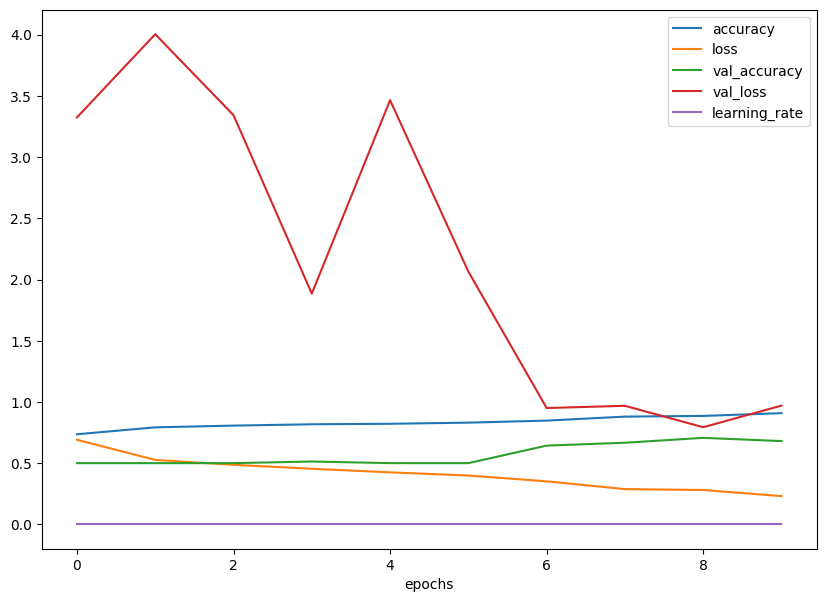

In [ ]:
import pandas as pd
pd.DataFrame(history_1.history).plot(figsize=(10,7), xlabel="epochs")

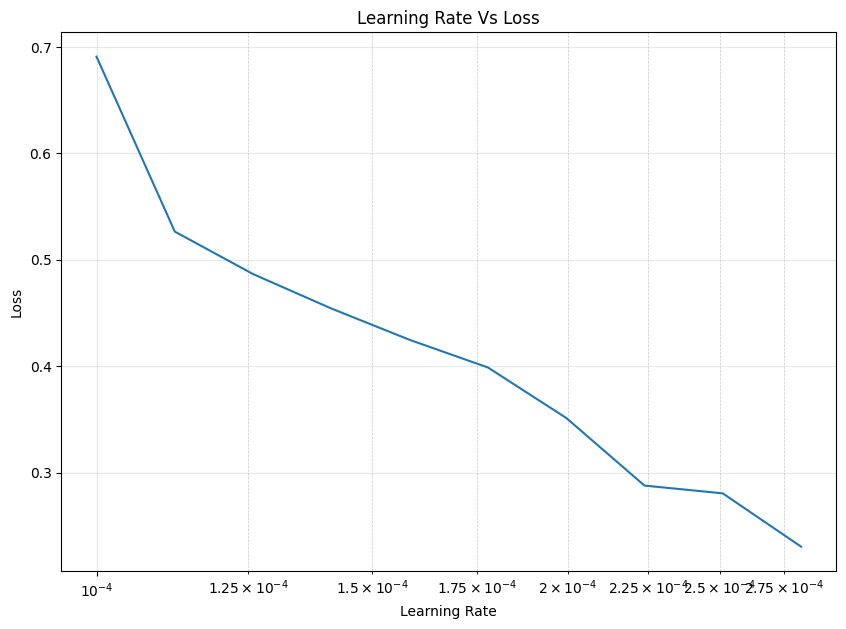

In [ ]:
def plot_lr_vs_loss(history, num_lrs=100):
    """
    Plot Learning Rate vs Loss with grid
    """
    lrs = 1e-4 * (10 ** (tf.range(num_lrs)/20))

    plt.figure(figsize=(10,7))
    plt.semilogx(lrs[:len(history.history["loss"])], history.history["loss"])
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("Learning Rate Vs Loss")

    # Add grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.3)

    plt.show()

# Use it
plot_lr_vs_loss(history_1)

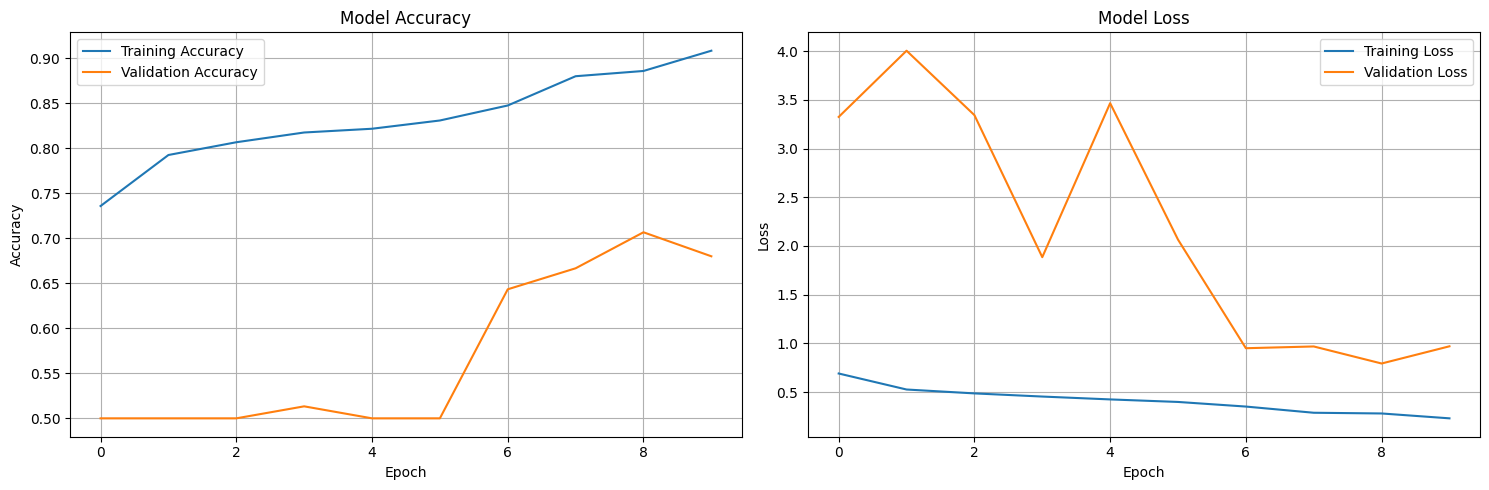

In [ ]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Plot training & validation loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_1)

In [ ]:
# Let's try using a higher ideal learning rate with thesame model

# Set random seed
tf.random.set_seed(42)

# Create Model
model_2 = tf.keras.models.Sequential(
    [
    tf.keras.Input(shape=(224, 224, 3)), # Explicitly define input shape
    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [ ]:
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=10e-3),
                metrics=["accuracy"])

In [ ]:
# Fit the model
history_2 = model_2.fit(
    train_data,
    epochs=10,  # Increased epochs with early stopping
    steps_per_epoch=len(train_data),
    validation_data=val_data,
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 421ms/step - accuracy: 0.7142 - loss: 0.6648 - val_accuracy: 0.5000 - val_loss: 1.0931
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.7817 - loss: 0.5170 - val_accuracy: 0.5000 - val_loss: 1.8215
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.8050 - loss: 0.4674 - val_accuracy: 0.5000 - val_loss: 2.1171
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.8208 - loss: 0.4067 - val_accuracy: 0.5000 - val_loss: 2.6405
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - accuracy: 0.8458 - loss: 0.3860 - val_accuracy: 0.5000 - val_loss: 2.5968
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 228ms/step - accuracy: 0.8542 - loss: 0.3491 - val_accuracy: 0.5000 - val_loss: 2.3754
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 223ms/step - accuracy: 0.8350 - loss: 0.3654 - val_accuracy: 0.5000 - val_loss: 2.6748
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.8817 - loss: 0.2939 - val_accuracy: 0

In [ ]:
result = model_1.evaluate(test_data)

print(f"The test Loss: {result[0]:.4f}")
print(f"Test Accuracy: {result[1]*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 262ms/step - accuracy: 0.7360 - loss: 0.6115
The test Loss: 0.6115
Test Accuracy: 73.60%


In [ ]:
result_2 = model_1.evaluate(test_data)

print(f"The test Loss: {result_2[0]:.4f}")
print(f"Test Accuracy: {result_2[1]*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.7360 - loss: 0.6115
The test Loss: 0.6115
Test Accuracy: 73.60%


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np # Import numpy for rounding

# Make predictions
y_preds_1 = model_1.predict(test_data)
y_preds_2 = model_2.predict(test_data)

# Convert probabilities to binary class labels for y_preds_1
y_pred_classes_1 = np.round(y_preds_1).flatten()

# Get the true labels from the test_data generator
y_true = test_data.classes

# Create Confusion Matrix for model_1
print("Confusion Matrix for Model 1:")
print(confusion_matrix(y_true, y_pred_classes_1))


y_pred_classes_2 = np.round(y_preds_2).flatten()
print("\nConfusion Matrix for Model 2:")
print(confusion_matrix(y_true, y_pred_classes_2))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Confusion Matrix for Model 1:
[[248   2]
 [130 120]]

Confusion Matrix for Model 2:
[[250   0]
 [229  21]]


Confusion Matrix for Model 1:


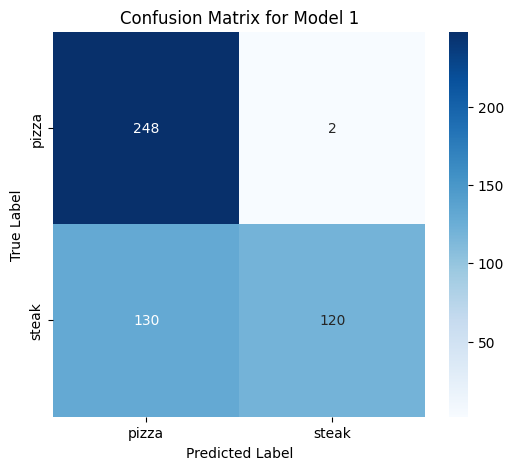

Confusion Matrix for Model 2:


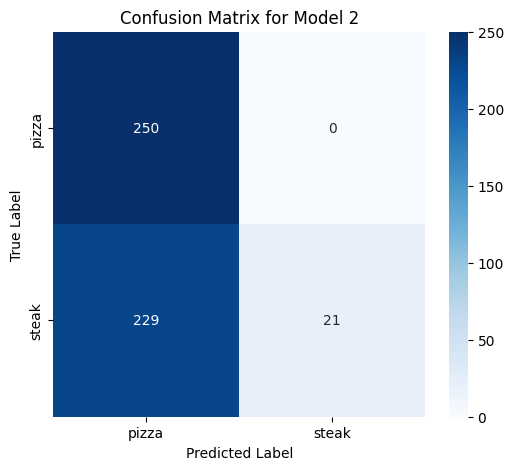

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred_classes, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

# Assuming class_names is available from previous cells
# If not, define it: class_names = ['pizza', 'steak']

# Plot Confusion Matrix for Model 1
print("Confusion Matrix for Model 1:")
plot_confusion_matrix(y_true, y_pred_classes_1, class_names, title="Confusion Matrix for Model 1")

# Plot Confusion Matrix for Model 2
print("Confusion Matrix for Model 2:")
plot_confusion_matrix(y_true, y_pred_classes_2, class_names, title="Confusion Matrix for Model 2")